## 이상치 제거 (Outlier Detection & Removal)

![](https://velog.velcdn.com/images/newnew_daddy/post/6a1e20c2-da20-4dcd-89be-6db0a794840e/image.png)

#### **이상치(Outlier)** 란 관측된 데이터의 일반적인 분포에서 크게 벗어난 극단적인 값을 의미한다.
- 이상치는 평균·분산 등 통계량을 왜곡하고, 모델이 소수의 극단값에 과적합되는 원인이 될 수 있어 전처리 단계에서 적절한 처리가 필수적이다.
- 다만, "크게 벗어난"의 기준은 주관적일 수 있으므로 통계적 방법론을 활용해 **일관적이고 재현 가능한 기준**으로 탐지·제거한다.

#### 이상치를 처리해야 하는 이유
- **통계량 왜곡**: 평균·표준편차 등이 극단값에 의해 크게 변동하여 데이터의 실제 경향을 반영하지 못한다.
- **모델 성능 저하**: 회귀 모델에서 기울기가 왜곡되고, 분류 모델에서 결정 경계가 비정상적으로 형성될 수 있다.
- **일반화 능력 감소**: 극단값에 과적합되어 새로운 데이터에 대한 예측 성능이 떨어진다.

#### 주요 탐지 방법 비교
| 구분 | IQR (사분위수 기반) | Z-Score (표준편차 기반) |
|---|---|---|
| **기준** | Q1 - 1.5×IQR ~ Q3 + 1.5×IQR 범위 밖 | 평균 ± 2~3σ 범위 밖 |
| **분포 가정** | 없음 (비모수적) | 정규분포를 가정 |
| **이상치 민감도** | 중앙값·IQR 기반이라 이상치에 강건 | 평균·표준편차가 이상치에 영향받음 |
| **적합 상황** | 분포를 모르거나 비대칭인 데이터 | 정규분포에 가까운 데이터 |
| **시각화** | 박스플롯 (Box Plot) | 히스토그램 / KDE |

#### 1. IQR(Inter Quantile Range) - 사분위수 기반
<img src="https://velog.velcdn.com/images/newnew_daddy/post/496a9887-06c8-4afc-8fef-8f4de7913875/image.png" width="60%">

[출처 : wikipedia]

- IQR 방법은 데이터의 중앙값과 사분위수를 기반으로 이상치를 검출합니다. 주로 비정규 분포 데이터에 유용합니다.
- 사분위 : 데이터를 4등분 했을 때의 범위
  - Q1 : 데이터의 하위 25%에 해당하는 값
  - Q2 : 데이터의 절반. 즉, 중앙값
  - Q3 : 데이터의 상위 25%에 해당하는 값
  - IQR : Q3 - Q1
  - IQR의 1.5배를 Q1에서 빼고, Q3에 더했을 때, 그 범위 밖에 있는 값들을 이상치로 간주.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("dataset/outlier.csv")

<Axes: >

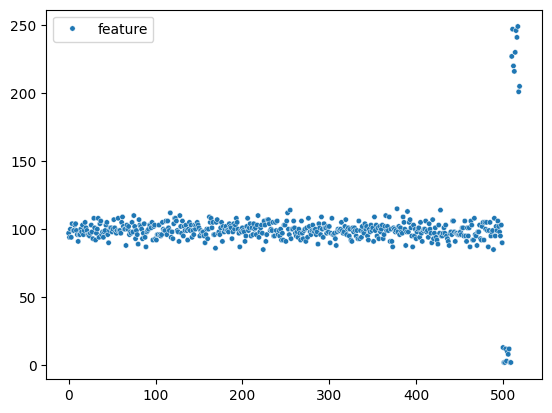

In [3]:
sns.scatterplot(data=df, s=15)

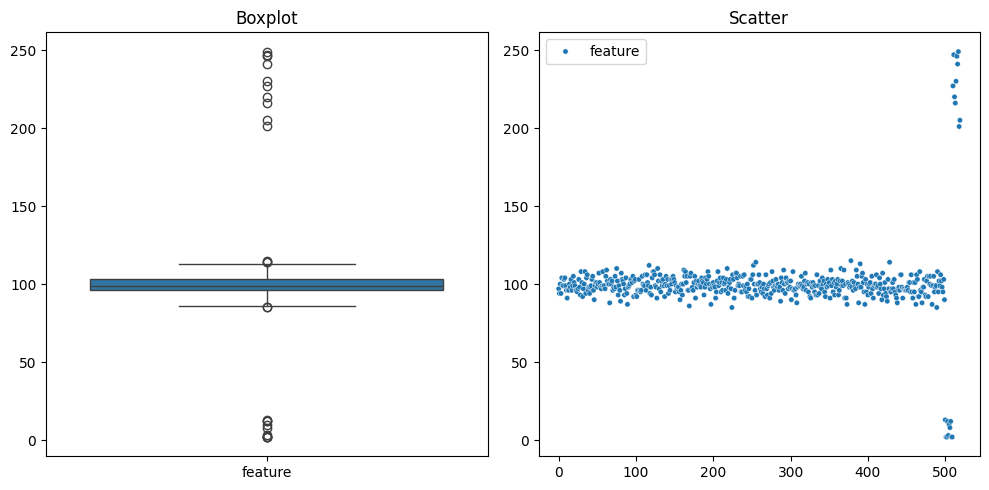

In [4]:
# Boxplot을 통해 이상치 시각화
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=df)
plt.title('Boxplot')

# Scatter plot을 통해 이상치 시각화
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, s=15)
plt.title('Scatter')

plt.tight_layout()
plt.show()

In [5]:
Q1 = df['feature'].quantile(0.25)
Q3 = df['feature'].quantile(0.75)

IQR = Q3 - Q1

cond1 = df['feature'] > (Q1 - 1.5 * IQR)
cond2 = df['feature'] < (Q3 + 1.5 * IQR)

iqr_filtered_df = df[cond1&cond2]


len(df), len(iqr_filtered_df)

(520, 495)

In [29]:
# IQR 방법
Q1 = df['feature'].quantile(0.25)
Q3 = df['feature'].quantile(0.75)
IQR = Q3 - Q1
iqr_filtered_df = df[(df['feature'] >= (Q1 - 1.5 * IQR)) & (df['feature'] <= (Q3 + 1.5 * IQR))]

len(df), len(iqr_filtered_df)

(120, 100)

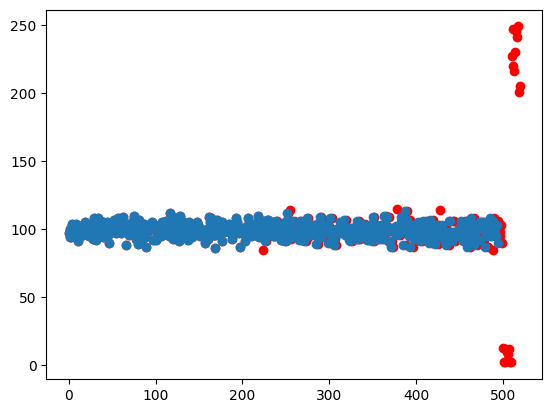

In [ ]:
# 빨간색이 IQR 적용 전, 파란색이 IQR 적용 후

plt.scatter(range(len(df)), df['feature'], c='red')
plt.scatter(range(len(iqr_filtered_df)), iqr_filtered_df['feature'])

#### 2. Z-Score (표준편차 기반 이상치 제거)

![](https://velog.velcdn.com/images/newnew_daddy/post/aece5c38-10ec-41ca-b70c-eae45b875623/image.png)


- 데이터의 평균과 표준편차를 계산하여, 일반적인 범위를 벗어난 데이터를 이상치로 간주
- 일반적으로 평균에서 ±3개의 표준편차 이상으로 떨어진 데이터를 이상치로 판단.

![](https://velog.velcdn.com/images/newnew_daddy/post/57bceac8-0278-4c46-88c0-4861ef80dfa3/image.png)

- **예시**
  - 주어진 데이터 집합의 평균이 100, 표준편차가 10 일 때,
  - 이상치 기준
    - μ−3σ=50−3⋅10=20 이하  or  μ+3σ=50+3⋅10=80 이상
  - 88인 지점의 Z-Score
    - (X-평균) / 표준편차  =  (88-100) / 10  =  -1.2



In [11]:
df = pd.read_csv('./dataset/outlier.csv')

In [12]:
def zscore_filter(df, zscore):
    
    mean = np.mean(df['feature'])
    std = np.std(df['feature'])
    z_filtered_df = df[(df['feature'] >= mean - zscore * std) & (df['feature'] <= mean + zscore * std)]
    
    return z_filtered_df

In [13]:
filtered_df = zscore_filter(df, 3)

len(df), len(filtered_df)

(520, 500)

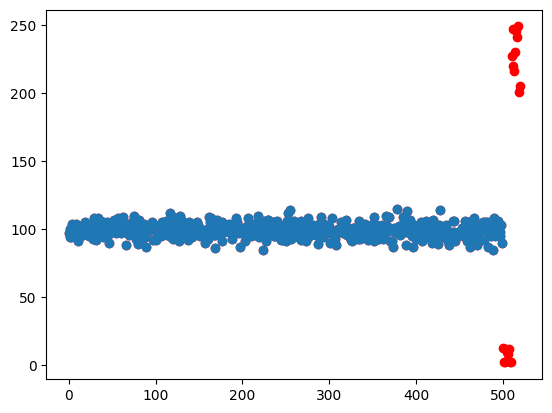

In [ ]:
# 빨간색이 Z-score 적용 전, 파란색이 Z-score 적용 후

plt.scatter(range(len(df)), df['feature'], c='red')
plt.scatter(range(len(filtered_df)), filtered_df['feature'])